# Cluster 13 dataframe

Notebook extraido de `Euclid_clustering.ipynb` dejando solo el flujo minimo para:

1. cargar `representations_pca_40.parquet`
2. reconstruir `work_df`
3. entrenar BIRCH con la misma configuracion
4. obtener `cluster_13_df`


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from IPython.display import display
from tqdm.notebook import tqdm
from sklearn.cluster import Birch
from sklearn.preprocessing import StandardScaler

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass


Mounted at /content/drive


# Morphology catalogue

In [3]:
MORPH_PATH = "/content/drive/MyDrive/catalogues/morphology_catalogue/morphology_catalogue.parquet"
LENS_PATH = "/content/drive/MyDrive/catalogues/strong_lensing_catalogue/q1_discovery_engine_lens_catalog.csv"

morph_df = pd.read_parquet(MORPH_PATH)
morph_df["object_id"] = morph_df["object_id"].astype("string")

lens_df = pd.read_csv(
    LENS_PATH,
    dtype={"object_id": "string"}
)

print(morph_df.shape)
print(lens_df.shape)

# Solo candidatas grade A
lens_grade_a_df = lens_df[lens_df["grade"].astype(str).str.upper() == "A"].copy()

# Flag: la candidata está en morphology?
morph_id_set = set(morph_df["object_id"].dropna())
lens_grade_a_df["found_in_morphology"] = lens_grade_a_df["object_id"].isin(morph_id_set)

print("Total grade A:", len(lens_grade_a_df))
print("Grade A encontradas en morphology:", lens_grade_a_df["found_in_morphology"].sum())

(380111, 74)
(2584, 13)
Total grade A: 309
Grade A encontradas en morphology: 156


# Lentes encontradas en morphology catalogue

In [4]:
# Dataframe solamente con la lentes encontradas en morphology
lens_grade_a_found_df = lens_grade_a_df[
    lens_grade_a_df["found_in_morphology"]
].copy()

object_id_list = lens_grade_a_found_df["object_id"].tolist()
print("Grade A encontradas en morphology:", len(object_id_list))

Grade A encontradas en morphology: 156


# PCA 40

In [5]:
PARQUET_PATH = "/content/drive/MyDrive/catalogues/morphology_catalogue/representations_pca_40.parquet"

BATCH_SIZE = 25000
TARGET_CLUSTER = 13


In [6]:
pca_40_df = pd.read_parquet(PARQUET_PATH)
pca_40_df["object_id"] = pca_40_df["id_str"].str.split("_").str[-1]

feature_cols = [c for c in pca_40_df.columns if c.startswith("feat_pca_")]

work_df = (
    pca_40_df
    .drop(columns=["hdf5_loc"], errors="ignore")
    .dropna(subset=feature_cols)
    .reset_index(drop=True)
    .copy()
)

print(f"Tamaño work_df: {len(work_df)}")
display(work_df.head())

Tamaño work_df: 380111


,id_str,feat_pca_0,feat_pca_1,feat_pca_2,feat_pca_3,feat_pca_4,feat_pca_5,feat_pca_6,feat_pca_7,feat_pca_8,...,feat_pca_31,feat_pca_32,feat_pca_33,feat_pca_34,feat_pca_35,feat_pca_36,feat_pca_37,feat_pca_38,feat_pca_39,object_id
0,Q1_R1_102018212_-584621148513532479,5.825709,-4.425679,4.202449,5.319937,-3.626957,-1.630027,-7.217823,4.331374,4.019675,...,-1.476074,0.218480,-0.420466,-1.075833,-0.517186,0.229066,-0.362843,2.647942,0.146909,-584621148513532479
1,Q1_R1_102018212_-584624035514720812,-6.291848,5.575155,2.416174,13.011729,-10.295957,10.897153,-8.226314,-1.932359,-4.091836,...,-0.397792,0.726267,1.000896,0.702727,1.591872,-0.468885,-0.593421,-0.087794,0.854033,-584624035514720812
2,Q1_R1_102018212_-584626836513332298,-3.382316,4.782965,1.361326,11.608858,-10.420763,9.331551,-10.486584,-0.356178,-3.509623,...,-1.600483,1.545459,2.071830,-0.477126,2.577803,-0.673725,-3.999462,-1.450399,0.131438,-584626836513332298
3,Q1_R1_102018212_-584639046514022962,-0.396249,-1.768375,2.828708,7.399952,-5.070143,1.664685,-4.221730,1.253209,5.743574,...,0.508984,-0.847269,0.800331,-0.661599,0.883475,-1.075483,0.770702,1.064695,1.029756,-584639046514022962
4,Q1_R1_102018212_-584642125513332605,-2.790663,3.891310,1.710156,11.238357,-9.795353,8.007547,-9.847942,-0.461148,-2.444761,...,-1.637048,1.660792,1.762383,-1.261792,2.338930,-0.691344,-3.945135,-1.312509,-0.122281,-584642125513332605


In [7]:
X = work_df[feature_cols].to_numpy(dtype="float32")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clusterización: BIRCH

In [8]:
scaler = StandardScaler()

for start in tqdm(range(0, len(work_df), BATCH_SIZE), desc="Ajustando scaler"):
    end = min(start + BATCH_SIZE, len(work_df))
    X_batch = work_df.iloc[start:end][feature_cols].to_numpy(dtype=np.float32, copy=True)
    scaler.partial_fit(X_batch)

cluster_model = Birch(
    threshold=8.0,
    branching_factor=2,
    n_clusters=None,
    compute_labels=False,
)

for start in tqdm(range(0, len(work_df), BATCH_SIZE), desc="Entrenando BIRCH"):
    end = min(start + BATCH_SIZE, len(work_df))
    X_batch = work_df.iloc[start:end][feature_cols].to_numpy(dtype=np.float32, copy=True)
    X_batch = scaler.transform(X_batch, copy=False)
    cluster_model.partial_fit(X_batch)

cluster_model.partial_fit()

labels = np.empty(len(work_df), dtype=np.int32)

for start in tqdm(range(0, len(work_df), BATCH_SIZE), desc="Asignando clusters"):
    end = min(start + BATCH_SIZE, len(work_df))
    X_batch = work_df.iloc[start:end][feature_cols].to_numpy(dtype=np.float32, copy=True)
    X_batch = scaler.transform(X_batch, copy=False)
    labels[start:end] = cluster_model.predict(X_batch)

work_df["cluster"] = labels

cluster_sizes = work_df["cluster"].value_counts().sort_index()
print(f"Subclusters hoja: {len(cluster_model.subcluster_centers_)}")
print(f"Objetos en cluster {TARGET_CLUSTER}: {int(cluster_sizes.get(TARGET_CLUSTER, 0))}")
#display(cluster_sizes)


Subclusters hoja: 57
Objetos en cluster 13: 10630


# Distancias cluster 13

In [9]:
from sklearn.metrics import pairwise_distances

cluster_id = 13

mask = work_df["cluster"] == cluster_id
cluster_points = X_scaled[mask]

centroid = cluster_points.mean(axis=0, keepdims=True)
dists = pairwise_distances(cluster_points, centroid, metric="euclidean").ravel()

# Objeto canónico del cluster 13

In [10]:
# Objeto más cercano al centroide del clúster en el espacio PCA
local_idx = dists.argmin()
canonical_row = work_df.loc[mask].iloc[local_idx]

canonical_id_str = canonical_row["id_str"]
print("id_str:", canonical_id_str)

id_str: Q1_R1_102160611_2741371386686077693


# Objeto más anómalo del cluster 13

In [11]:
local_idx = dists.argmax()
anomaly_row = work_df.loc[mask].iloc[local_idx]

anomalous_id_str = anomaly_row["id_str"]
anomalous_score = dists[local_idx]

print("id_str:", anomalous_id_str)
print("anomaly_score:", anomalous_score)

id_str: Q1_R1_102020529_-566169771490540487
anomaly_score: 15.057851


# Cluster 13

In [12]:
cluster_13_df = work_df[work_df["cluster"] == TARGET_CLUSTER].copy()

print(f"cluster_13_df shape: {cluster_13_df.shape}")
display(cluster_13_df.head())


cluster_13_df shape: (10630, 43)


,id_str,feat_pca_0,feat_pca_1,feat_pca_2,feat_pca_3,feat_pca_4,feat_pca_5,feat_pca_6,feat_pca_7,feat_pca_8,...,feat_pca_32,feat_pca_33,feat_pca_34,feat_pca_35,feat_pca_36,feat_pca_37,feat_pca_38,feat_pca_39,object_id,cluster
7,Q1_R1_102018212_-584666237513511344,2.222745,9.530354,-4.754581,2.349840,0.856132,-1.072072,-1.209312,2.104651,0.077497,...,0.806725,0.353277,-0.104309,-0.120072,1.802917,0.839762,0.943147,-2.291334,-584666237513511344,13
8,Q1_R1_102018212_-584686171513792438,8.109252,-9.756514,-1.211491,6.113095,-2.212651,-1.646956,-0.382211,2.746773,1.868733,...,-0.002047,1.000679,-0.476660,-0.918004,0.254372,0.621632,0.107620,-0.888901,-584686171513792438,13
13,Q1_R1_102018212_-584765257513156026,-8.317151,0.327670,1.741003,5.344576,1.579226,1.976274,0.917539,-0.697545,3.480225,...,0.359526,0.244328,-0.840331,0.500288,-0.648902,0.724787,-0.552656,-0.804236,-584765257513156026,13
18,Q1_R1_102018212_-584880970512480635,3.795307,-4.264358,0.967754,-1.753258,-1.077826,2.426367,-1.236199,3.222602,3.192017,...,-0.273878,-0.435595,0.704200,-0.545079,0.078583,-0.180250,0.026433,-0.340567,-584880970512480635,13
21,Q1_R1_102018212_-584893480513231691,-1.016426,5.516606,-0.974393,2.393159,-1.016597,1.035390,5.620472,-2.098683,3.151832,...,-0.755349,0.273168,0.525291,-1.597633,1.145874,-0.754902,1.024532,-0.248162,-584893480513231691,13


# UMAP

Cluster 13: 10630 objetos
Lentes: 34
Canónicos: 0
Anómalos: 0


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


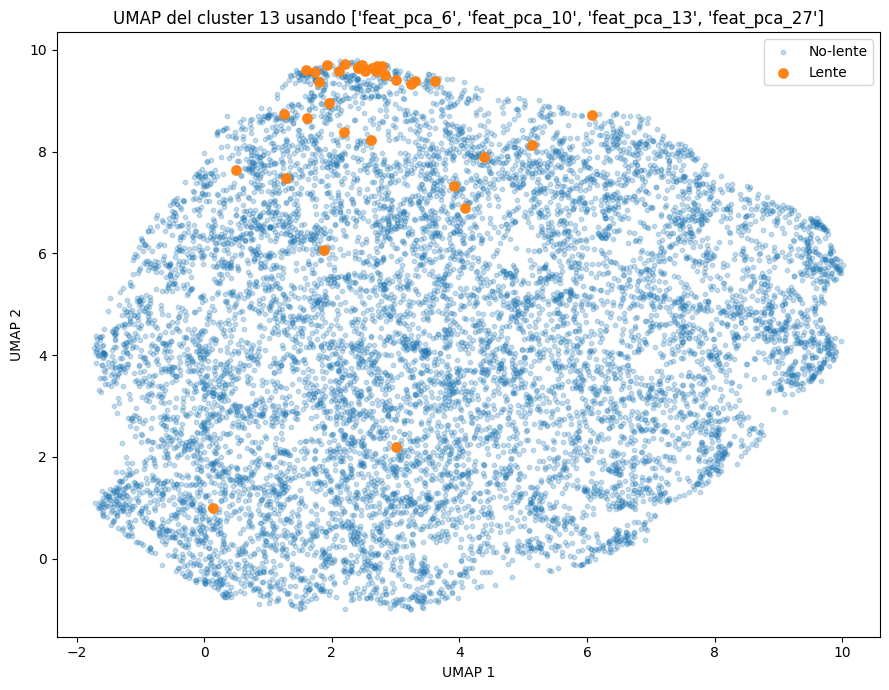

In [13]:
import umap.umap_ as umap

TARGET_CLUSTER = 13

selected_pca_features = [
    # Varianza
    #"feat_pca_0",
    #"feat_pca_1",
    #"feat_pca_2",
    #"feat_pca_3",

    # Información mutua
    #"feat_pca_6",
    #"feat_pca_27",
    #"feat_pca_12",
    #"feat_pca_32",

    # Mayor mean diff (componentes donde las lentes están desplazadas)
    #"feat_pca_6",
    #"feat_pca_0",
    #"feat_pca_12",
    #"feat_pca_1",

    # Mix componentes
    #"feat_pca_6",
    #"feat_pca_0",
    #"feat_pca_12",
    #"feat_pca_1",
    #"feat_pca_10",
    #"feat_pca_8",
    #"feat_pca_13",
    #"feat_pca_27",

    #-------
    #"feat_pca_1",
    #"feat_pca_12",
    #"feat_pca_6",
    #"feat_pca_10",
    #"feat_pca_13",
    #"feat_pca_27",
    #-------
    "feat_pca_6",
    "feat_pca_10",
    "feat_pca_13",
    "feat_pca_27",
]

# ============================================================
# IDS DEL CANÓNICO Y DEL ANÓMALO DEL CLUSTER 13
# ============================================================

canonical_id_str = "AQUI_EL_ID_STR_DEL_CANONICO"
anomaly_id_str = "AQUI_EL_ID_STR_DEL_ANOMALO"

# ============================================================
# PREPARAR DATAFRAME
# ============================================================

plot_df = work_df.copy()
plot_df["id_str"] = plot_df["id_str"].astype("string")
plot_df["object_id"] = plot_df["object_id"].astype("string")  # solo para detectar lentes

lens_ids = set(pd.Series(object_id_list, dtype="string").dropna().astype(str))
plot_df["is_lens"] = plot_df["object_id"].isin(lens_ids)

cluster_13_df = plot_df[plot_df["cluster"] == TARGET_CLUSTER].copy()

cluster_13_df["is_canonical"] = cluster_13_df["id_str"] == str(canonical_id_str)
cluster_13_df["is_anomaly"] = cluster_13_df["id_str"] == str(anomaly_id_str)

umap_df = cluster_13_df[
    ["id_str", "is_lens", "is_canonical", "is_anomaly"] + selected_pca_features
].copy()

umap_df = umap_df.dropna(subset=selected_pca_features).reset_index(drop=True)

print(f"Cluster {TARGET_CLUSTER}: {len(umap_df)} objetos")
print(f"Lentes: {int(umap_df['is_lens'].sum())}")
print(f"Canónicos: {int(umap_df['is_canonical'].sum())}")
print(f"Anómalos: {int(umap_df['is_anomaly'].sum())}")

# ============================================================
# UMAP
# ============================================================

X = umap_df[selected_pca_features].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=25,
    min_dist=0.15,
    n_components=2,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)

umap_df["umap_1"] = embedding[:, 0]
umap_df["umap_2"] = embedding[:, 1]

non_lens_df = umap_df[~umap_df["is_lens"]]
lens_df = umap_df[umap_df["is_lens"]]

# ============================================================
# VISUALIZACIÓN
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    non_lens_df["umap_1"],
    non_lens_df["umap_2"],
    s=10,
    alpha=0.25,
    label="No-lente"
)

plt.scatter(
    lens_df["umap_1"],
    lens_df["umap_2"],
    s=45,
    alpha=0.95,
    label="Lente"
)

canonical_plot_df = umap_df[umap_df["is_canonical"]]
anomaly_plot_df = umap_df[umap_df["is_anomaly"]]

if not canonical_plot_df.empty:
    plt.scatter(
        canonical_plot_df["umap_1"],
        canonical_plot_df["umap_2"],
        s=140,
        marker="*",
        label="Canonical"
    )

if not anomaly_plot_df.empty:
    plt.scatter(
        anomaly_plot_df["umap_1"],
        anomaly_plot_df["umap_2"],
        s=120,
        marker="X",
        label="Anomaly"
    )

plt.title(f"UMAP del cluster {TARGET_CLUSTER} usando {selected_pca_features}")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.tight_layout()
plt.show()

## Análisis de separabilidad entre lentes y no-lentes mediante thresholds

En esta sección pasamos de un análisis puramente visual (histogramas) a un enfoque cuantitativo para evaluar qué variables del espacio PCA permiten **separar mejor los objetos lente de los no-lente**.

Queremos encontrar un **umbral (threshold)** sobre una variable que permita definir una regla de clasificación simple del tipo:

- `feature > threshold → lente`
- `feature < threshold → lente`

La idea es comprobar si existe algún valor de las variables que divida el espacio en dos regiones donde una esté enriquecida en lentes.

---

## 1. Búsqueda del mejor threshold por variable para separar lentes / no-lentes

Para cada variable PCA:

1. Se toman todos los objetos del cluster (en este caso, cluster 13).
2. Se recorren múltiples valores posibles de threshold dentro del rango de la variable.
3. Para cada threshold se generan predicciones binarias (lente / no-lente).
4. Se evalúa la calidad de la separación usando métricas como:
   - **F1-score** (equilibrio entre precision y recall)
   - Precision
   - Recall
   - Accuracy
5. Se guarda el threshold que maximiza el F1-score.

Además, se calculan métricas independientes del threshold como:
- **ROC AUC**
- **Average Precision**

Esto nos permite cuantificar qué variables tienen mayor poder discriminativo.

In [14]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
)

# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------

TARGET_CLUSTER = 13

# Usa cluster_13_df si ya existe; si no, lo construimos desde work_df
if "cluster_13_df" in globals():
    analysis_df = cluster_13_df.copy()
else:
    analysis_df = work_df[work_df["cluster"] == TARGET_CLUSTER].copy()

# Si todavía no existe is_lens, lo creamos desde object_id_list
if "is_lens" not in analysis_df.columns:
    analysis_df["object_id"] = analysis_df["object_id"].astype("string")
    lens_ids = set(pd.Series(object_id_list, dtype="string").dropna().astype(str))
    analysis_df["is_lens"] = analysis_df["object_id"].isin(lens_ids)

# Features PCA disponibles
pca_features = [c for c in analysis_df.columns if c.startswith("feat_pca_")]

print(f"Cluster {TARGET_CLUSTER}: {len(analysis_df)} objetos")
print(f"Lentes: {analysis_df['is_lens'].sum()}")
print(f"No-lentes: {(~analysis_df['is_lens']).sum()}")
print(f"Features PCA detectadas: {len(pca_features)}")

# ------------------------------------------------------------
# FUNCIÓN PARA BUSCAR EL MEJOR CORTE DE UNA FEATURE
# ------------------------------------------------------------

def find_best_cut(df, feature, n_thresholds=300):
    values = df[[feature, "is_lens"]].dropna().copy()

    X = values[feature].to_numpy()
    y = values["is_lens"].astype(int).to_numpy()

    if len(np.unique(y)) < 2:
        return None

    thresholds = np.linspace(X.min(), X.max(), n_thresholds)

    best_result = None

    for direction in [">", "<"]:
        for t in thresholds:
            if direction == ">":
                y_pred = (X > t).astype(int)
            else:
                y_pred = (X < t).astype(int)

            result = {
                "feature": feature,
                "direction": direction,
                "threshold": t,
                "accuracy": accuracy_score(y, y_pred),
                "precision": precision_score(y, y_pred, zero_division=0),
                "recall": recall_score(y, y_pred, zero_division=0),
                "f1": f1_score(y, y_pred, zero_division=0),
                "n_selected": int(y_pred.sum()),
                "n_lenses_selected": int(((y_pred == 1) & (y == 1)).sum()),
                "n_total_lenses": int(y.sum()),
            }

            if best_result is None or result["f1"] > best_result["f1"]:
                best_result = result

    # Métricas ranking, independientes del threshold
    try:
        auc = roc_auc_score(y, X)
        ap = average_precision_score(y, X)
    except Exception:
        auc = np.nan
        ap = np.nan

    best_result["roc_auc_raw"] = auc
    best_result["average_precision_raw"] = ap

    return best_result

# ------------------------------------------------------------
# EJECUTAR ANÁLISIS PARA TODAS LAS FEATURES PCA
# ------------------------------------------------------------

results = []

for feature in pca_features:
    result = find_best_cut(analysis_df, feature)

    if result is not None:
        results.append(result)

cuts_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

display(cuts_df.head(15))

Cluster 13: 10630 objetos
Lentes: 34
No-lentes: 10596
Features PCA detectadas: 40


,feature,direction,threshold,accuracy,precision,recall,f1,n_selected,n_lenses_selected,n_total_lenses,roc_auc_raw,average_precision_raw
0,feat_pca_12,<,-6.310603,0.995014,0.086957,0.058824,0.070175,23,2,34,0.359653,0.002737
1,feat_pca_13,<,-3.505637,0.976011,0.037657,0.264706,0.065934,239,9,34,0.200880,0.001878
2,feat_pca_27,<,-2.738918,0.985042,0.037037,0.147059,0.059172,135,5,34,0.205105,0.001888
3,feat_pca_16,<,-3.488813,0.996896,1.000000,0.029412,0.057143,1,1,34,0.416356,0.002677
4,feat_pca_6,>,7.291375,0.993697,0.054054,0.058824,0.056338,37,2,34,0.828415,0.020232
5,feat_pca_32,<,-3.995887,0.996519,0.200000,0.029412,0.051282,5,1,34,0.309259,0.002152
6,feat_pca_29,>,3.007954,0.996425,0.166667,0.029412,0.050000,6,1,34,0.783165,0.016339
7,feat_pca_3,<,-7.129600,0.996143,0.111111,0.029412,0.046512,9,1,34,0.474466,0.002909
8,feat_pca_17,<,-2.362478,0.995014,0.047619,0.029412,0.036364,21,1,34,0.402968,0.004345
9,feat_pca_4,<,-9.683216,0.995014,0.047619,0.029412,0.036364,21,1,34,0.660832,0.005397


## 2. Visualización de los cortes para cada feature PCA

Para cada variable:

- Se representan los histogramas normalizados de objetos lente / no-lente.
- Se dibuja una línea vertical indicando el **mejor threshold encontrado**.
- Se muestran métricas asociadas al corte (F1, precision, recall).

Esto permite validar visualmente si el corte tiene sentido, además de permite identificar cuánto solapamiento hay entre ambas distribuciones y detectar variables con buena capacidad de separación.

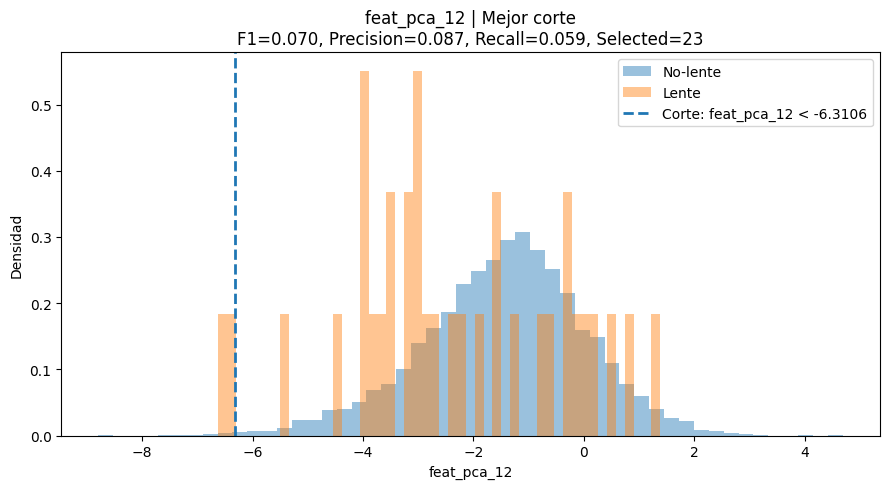

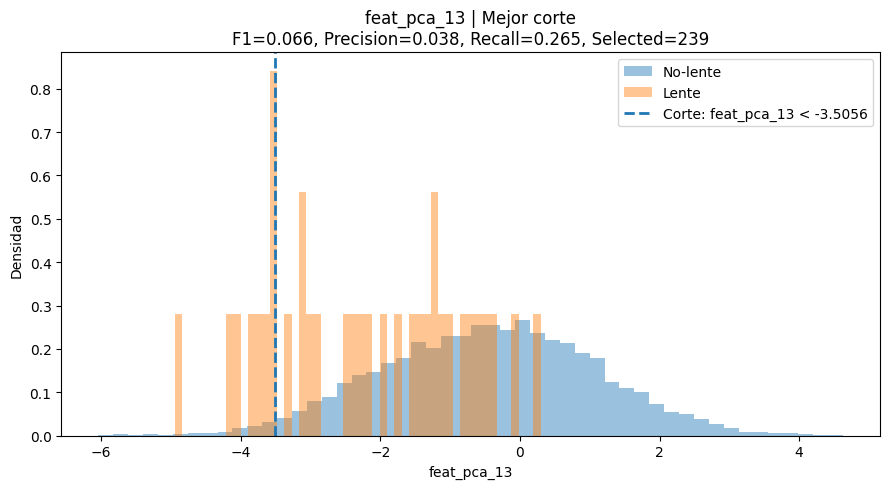

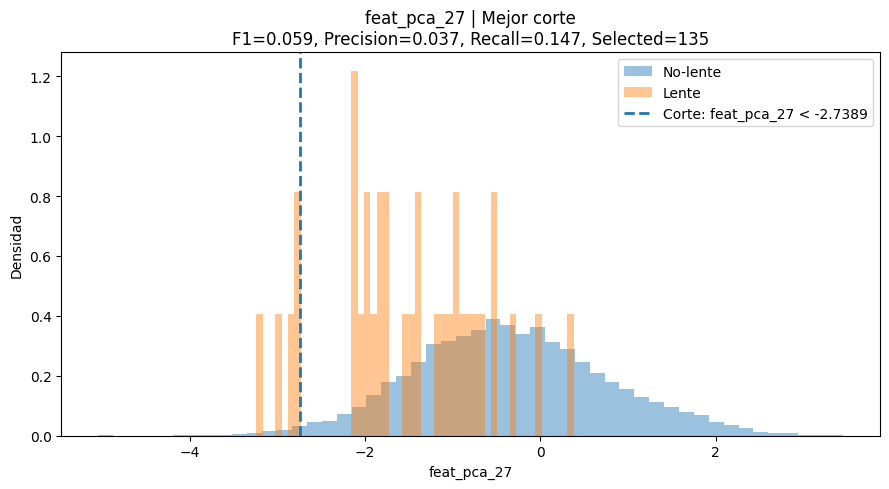

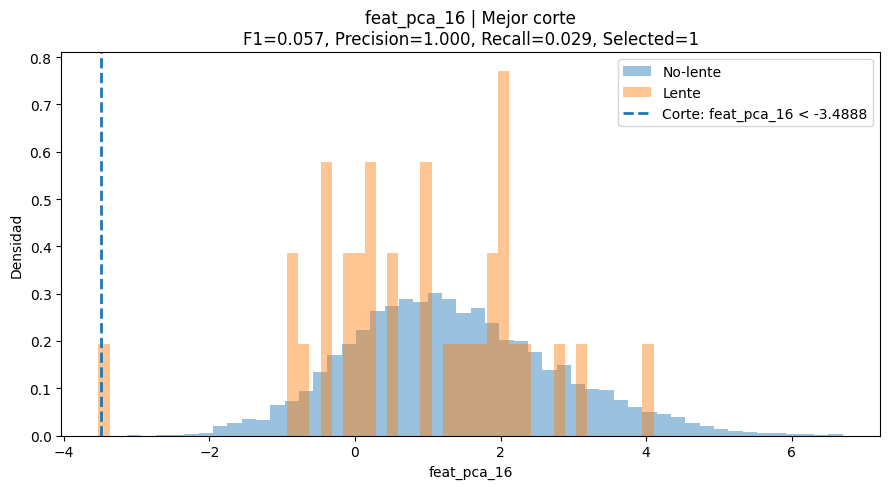

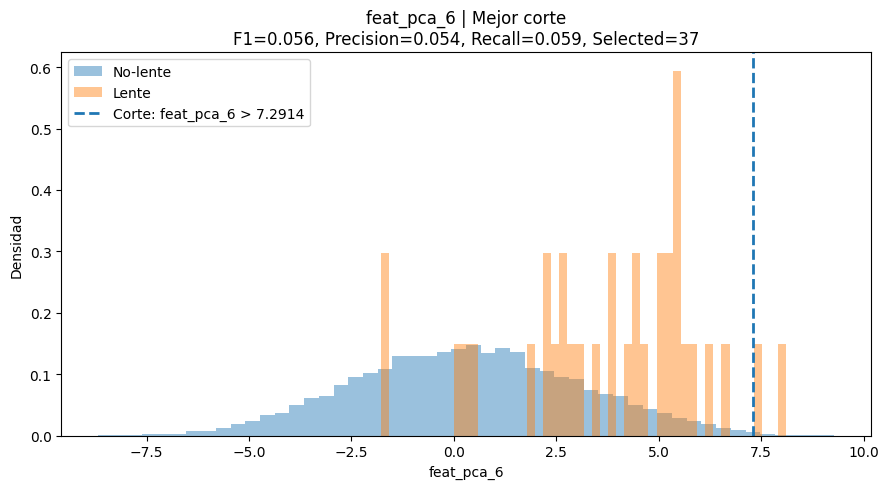

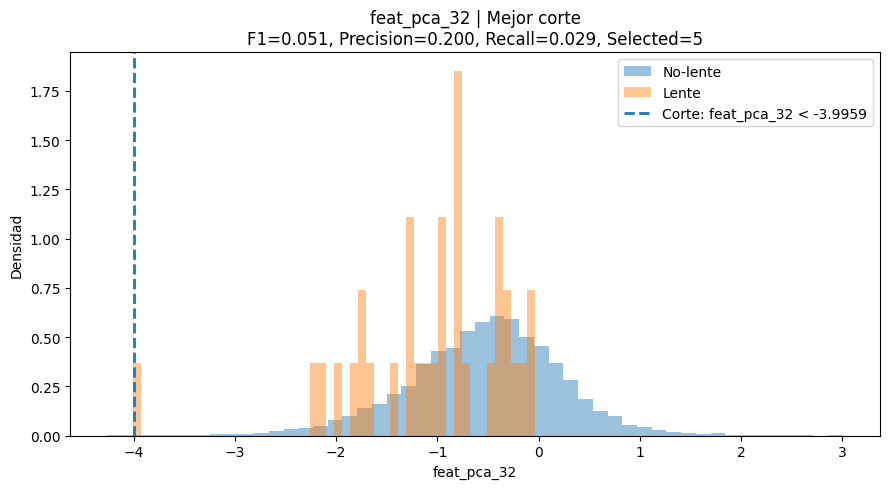

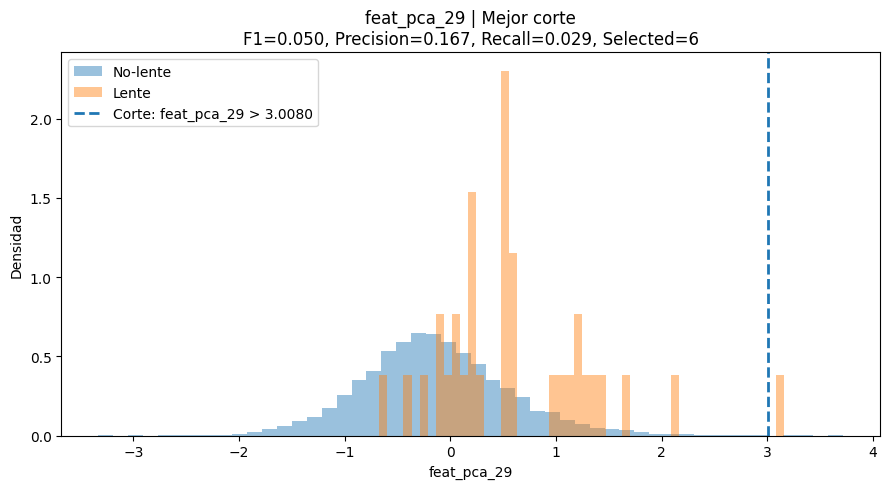

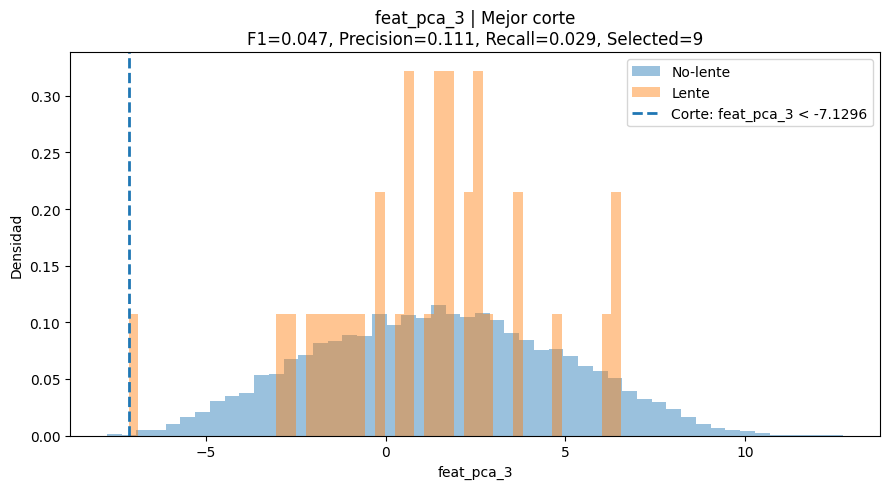

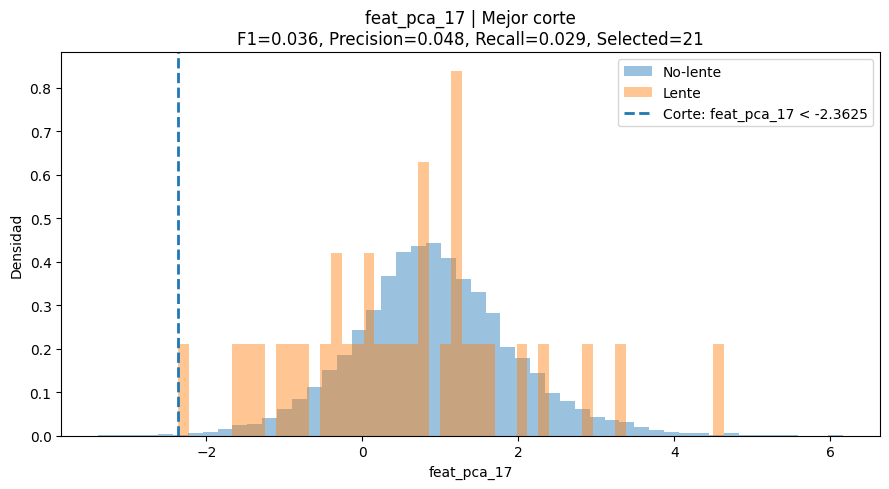

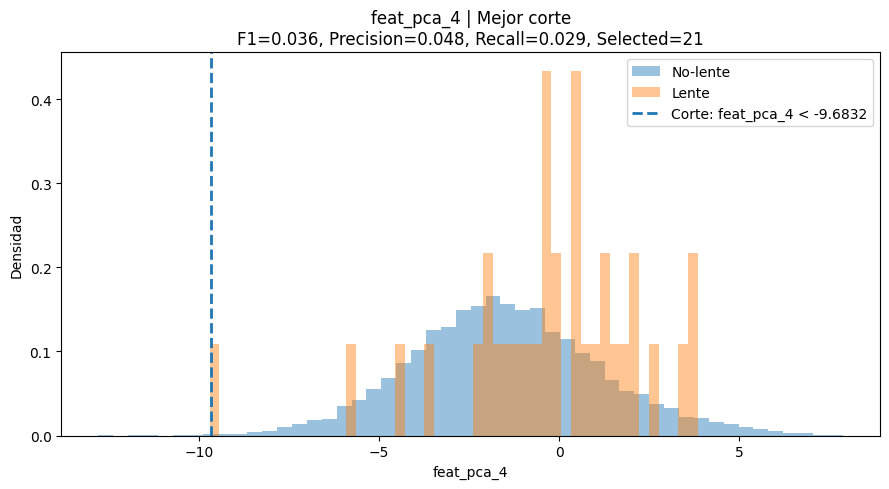

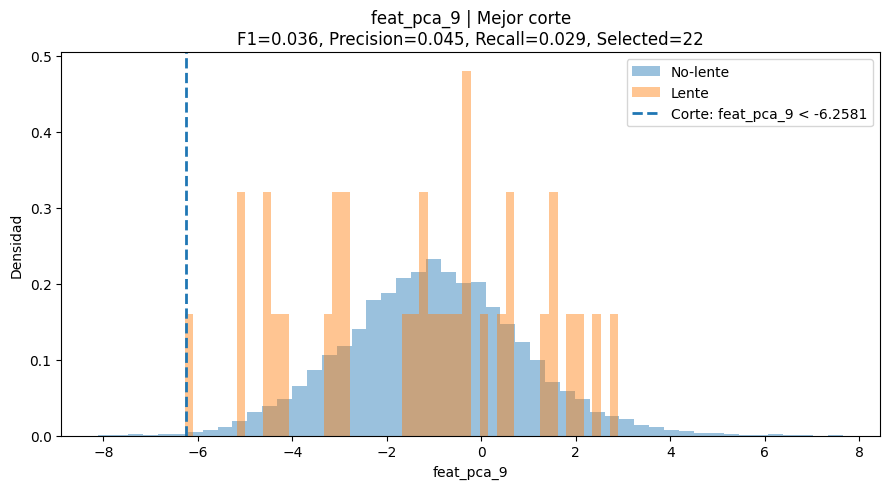

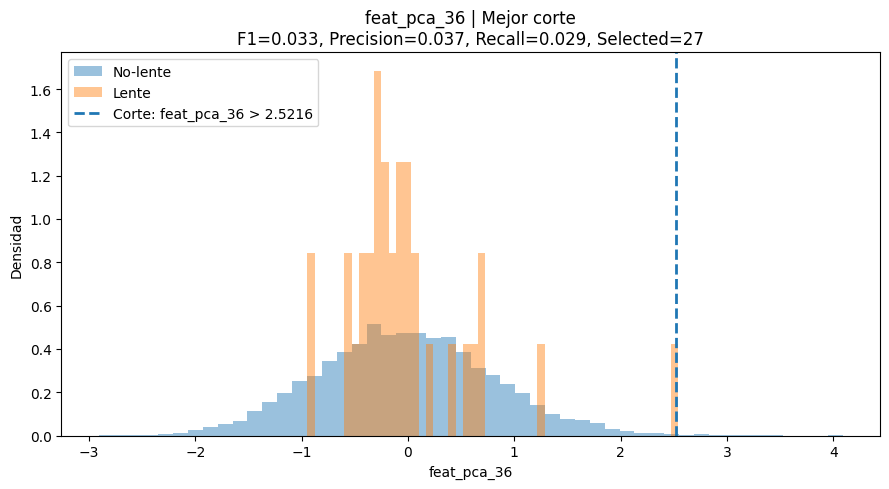

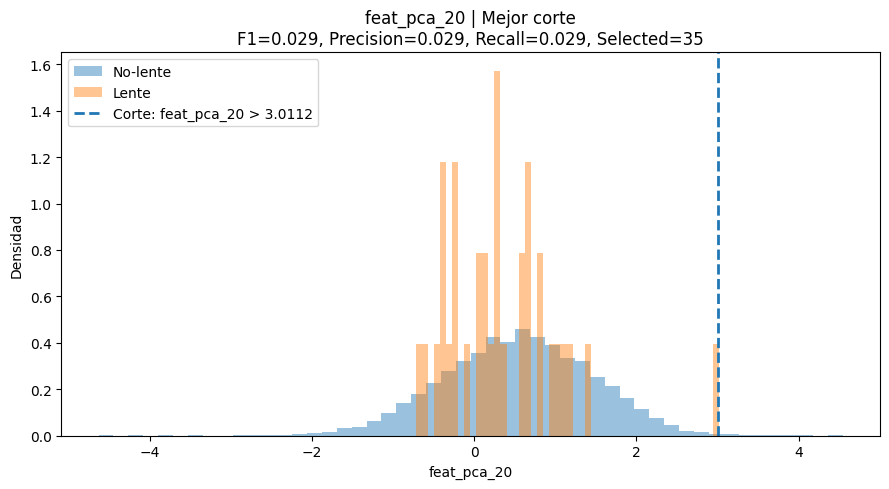

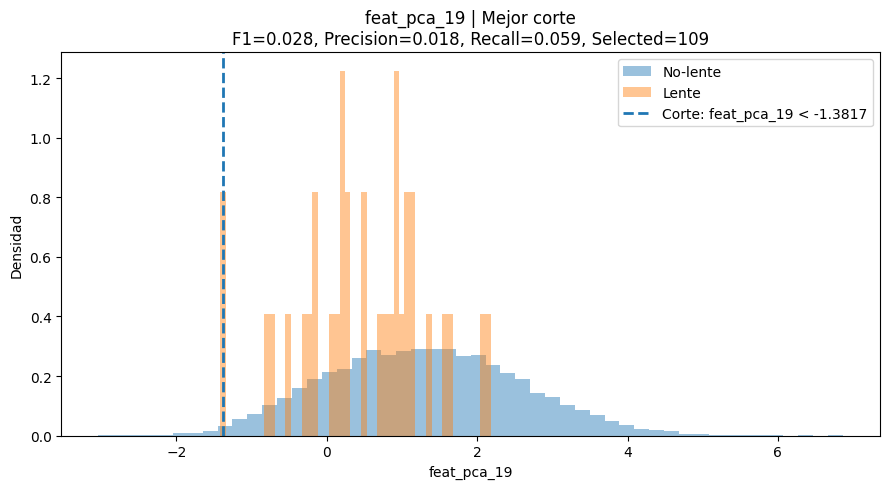

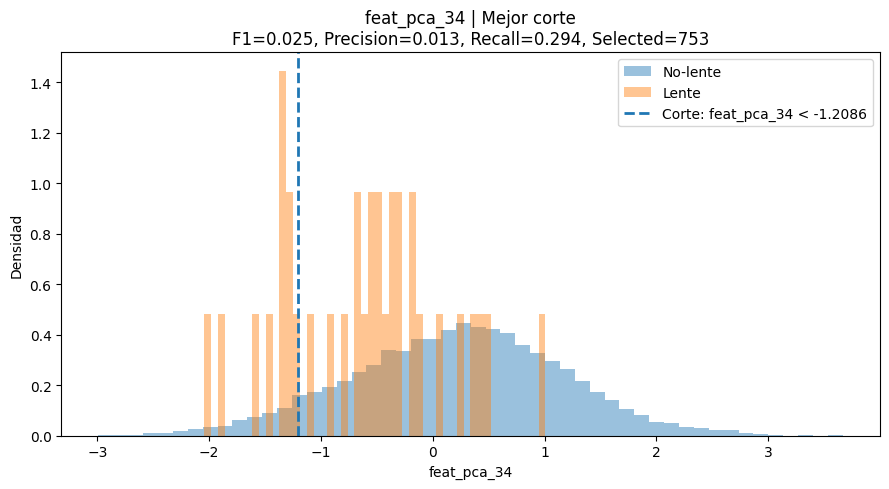

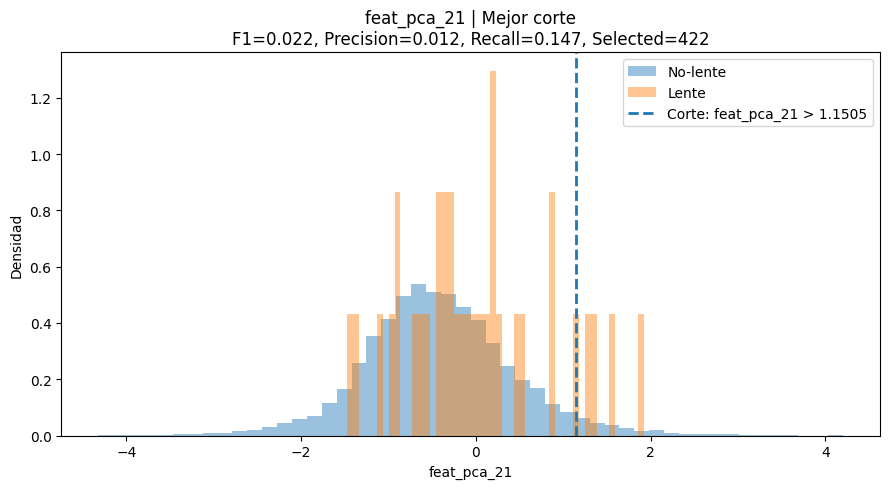

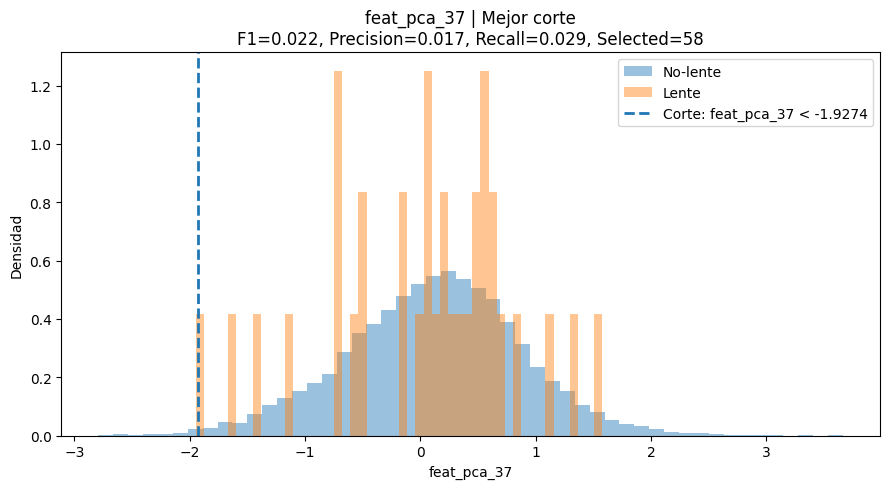

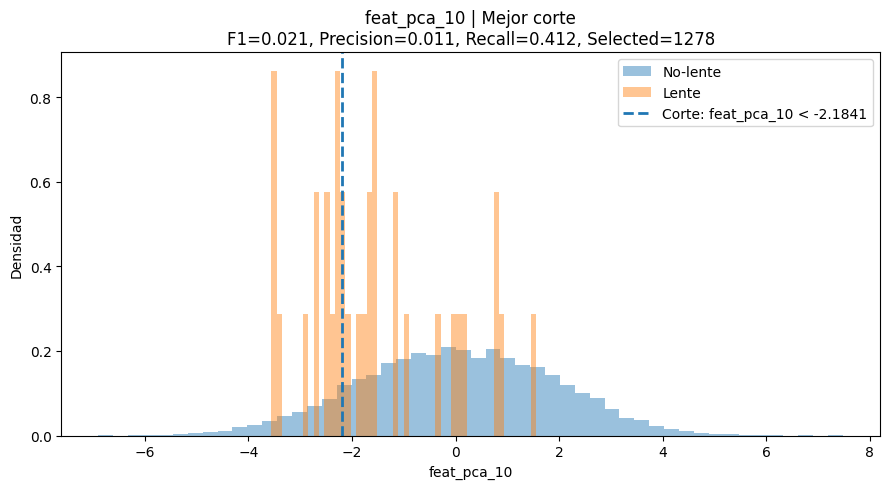

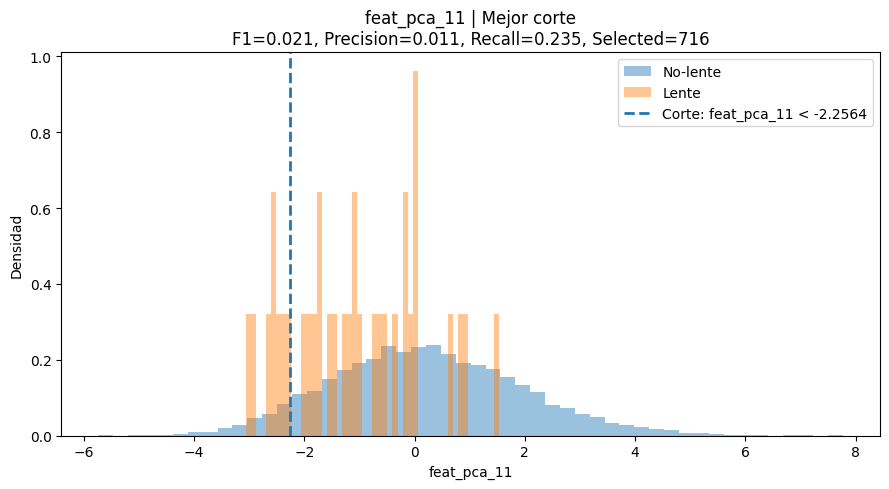

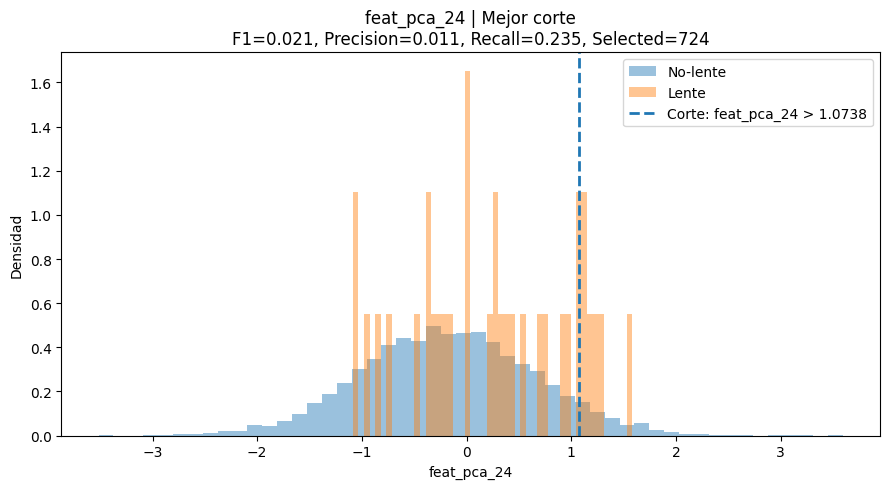

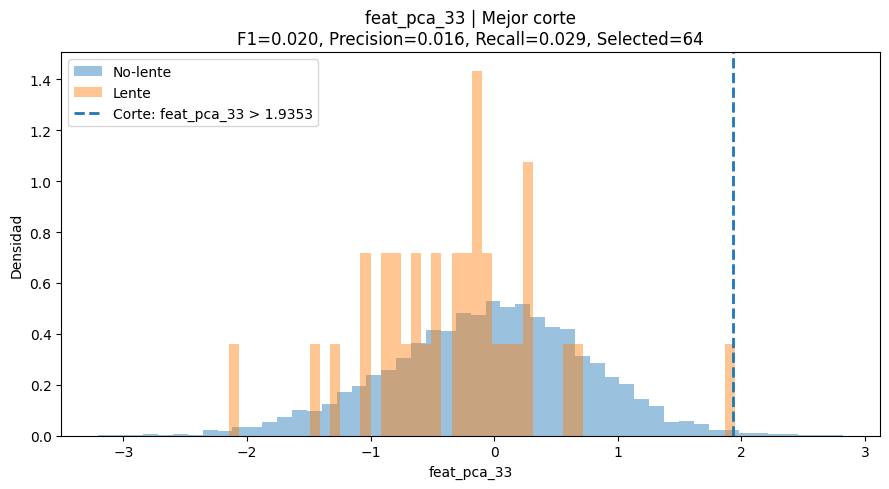

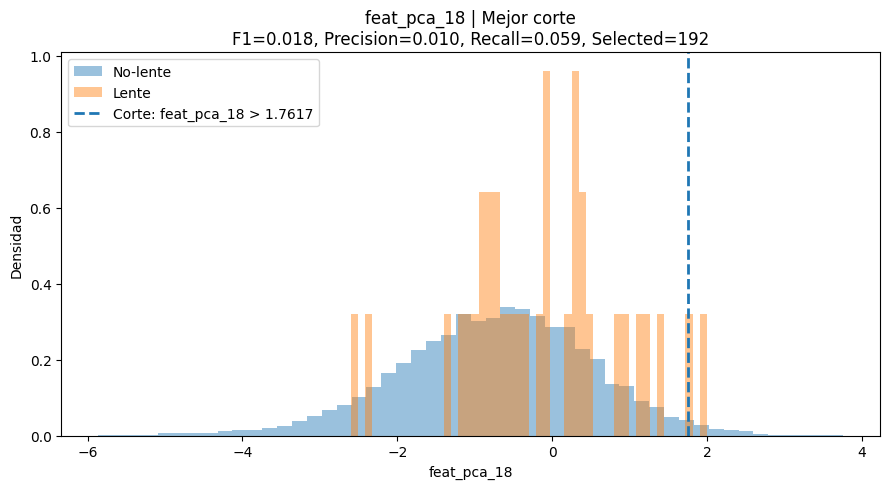

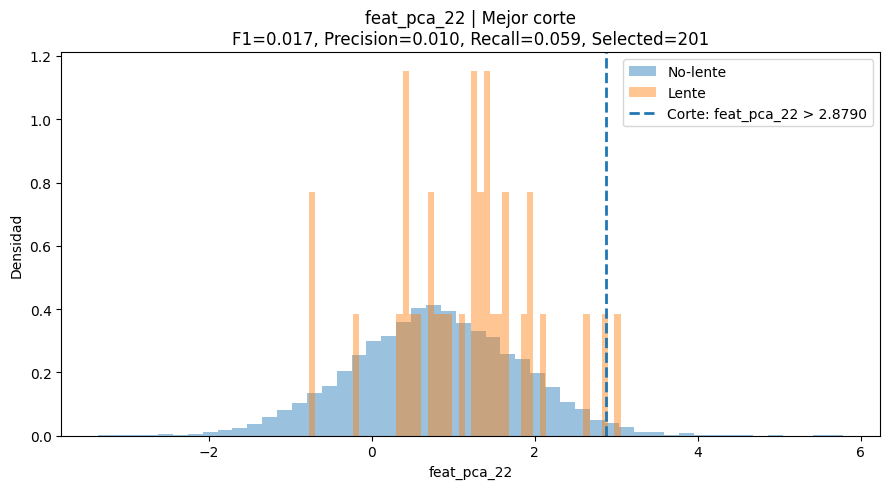

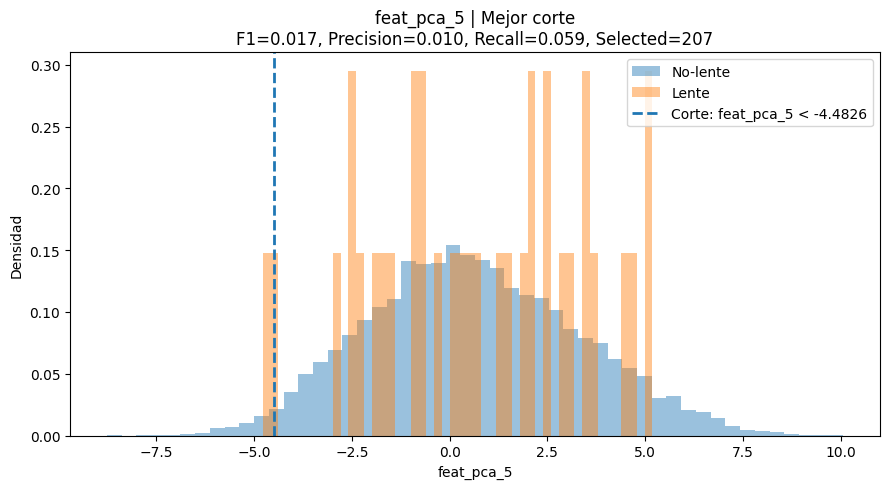

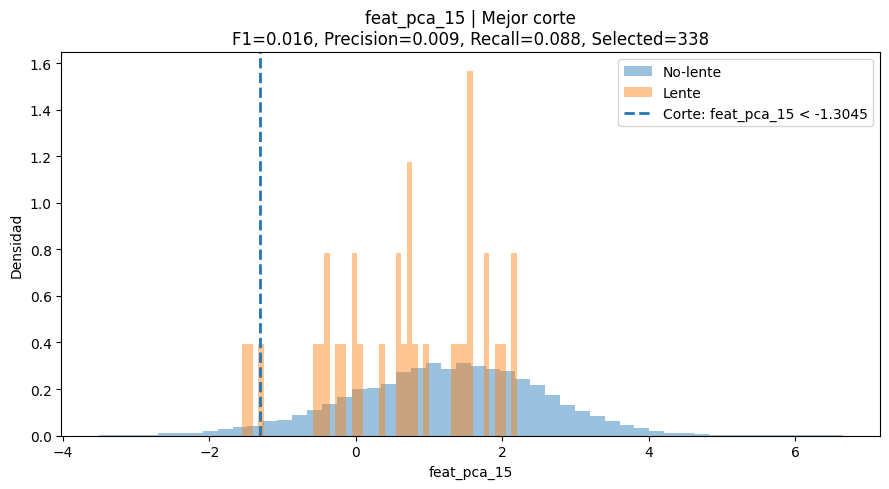

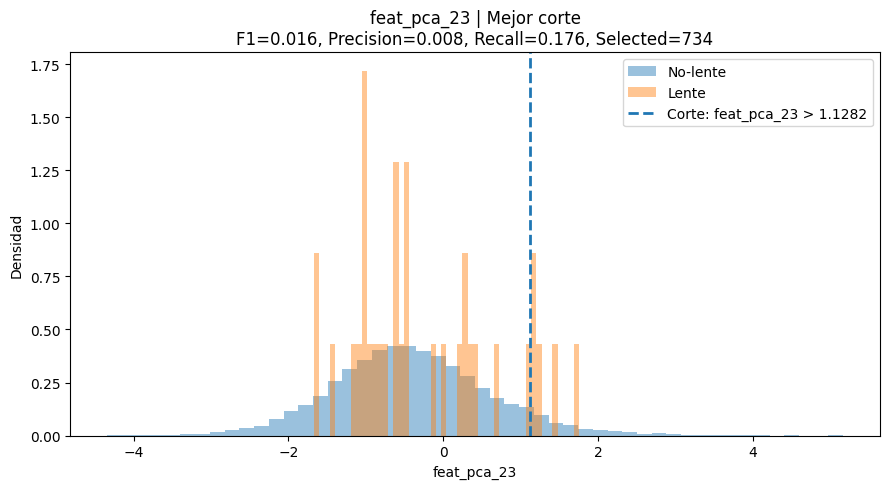

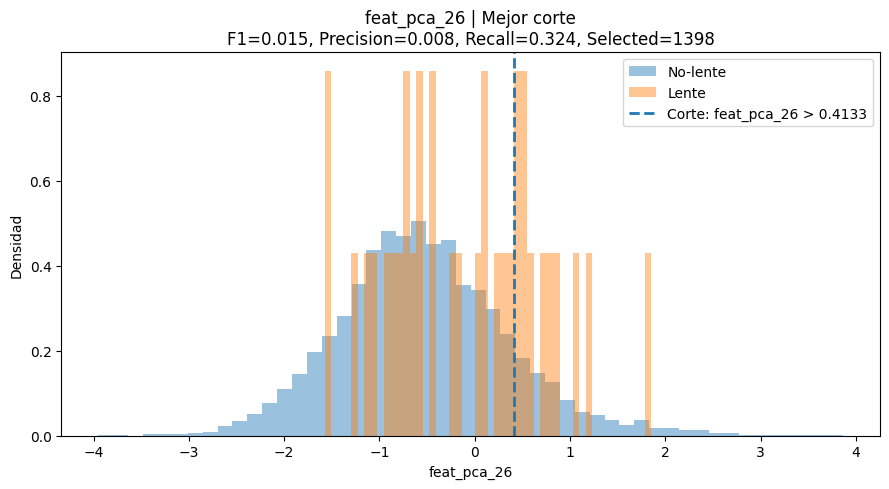

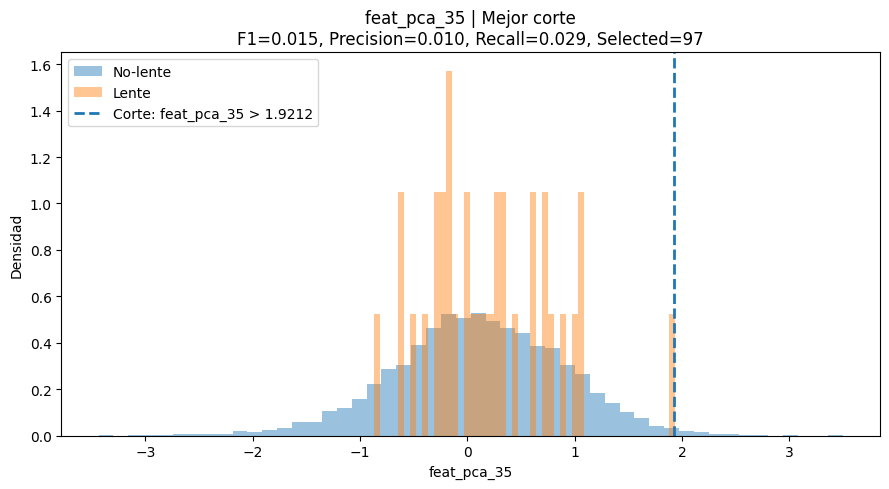

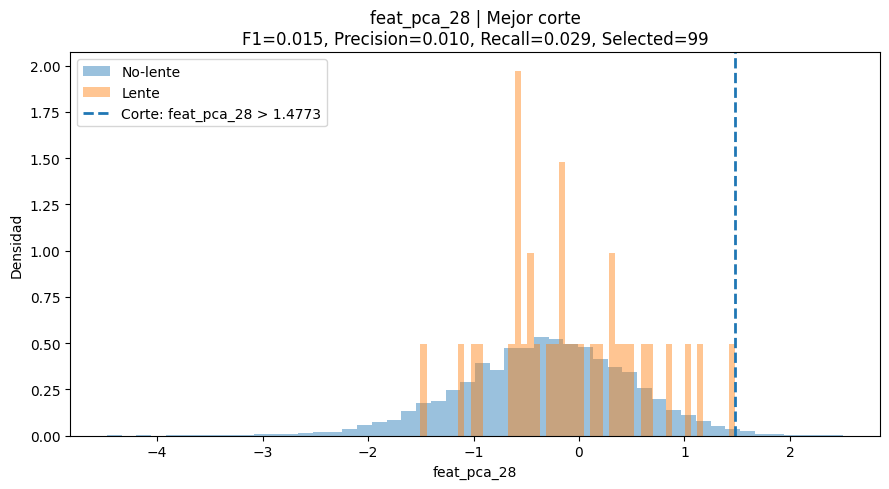

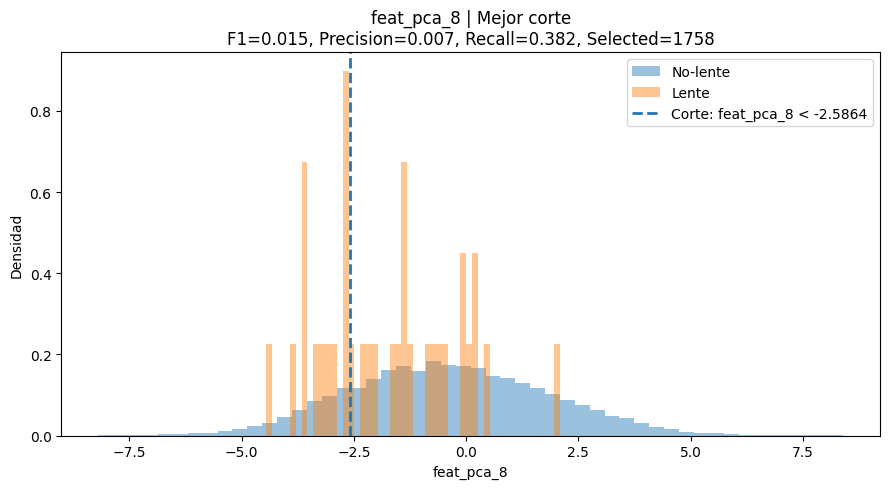

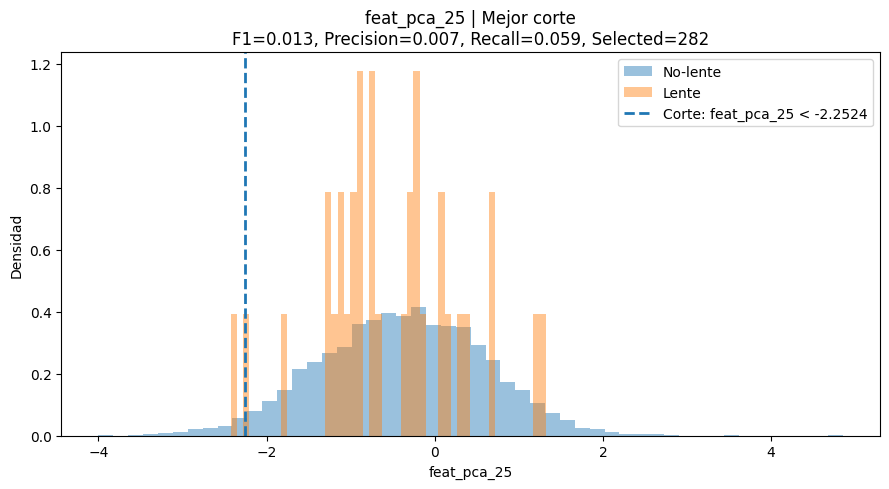

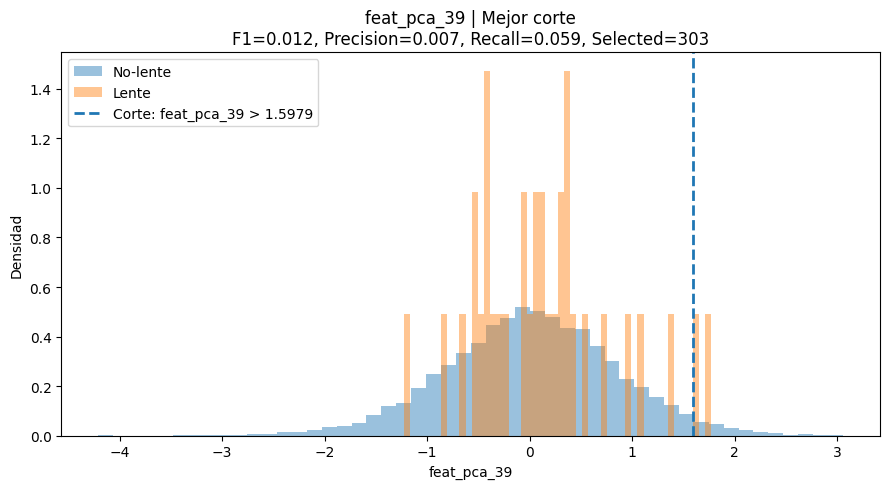

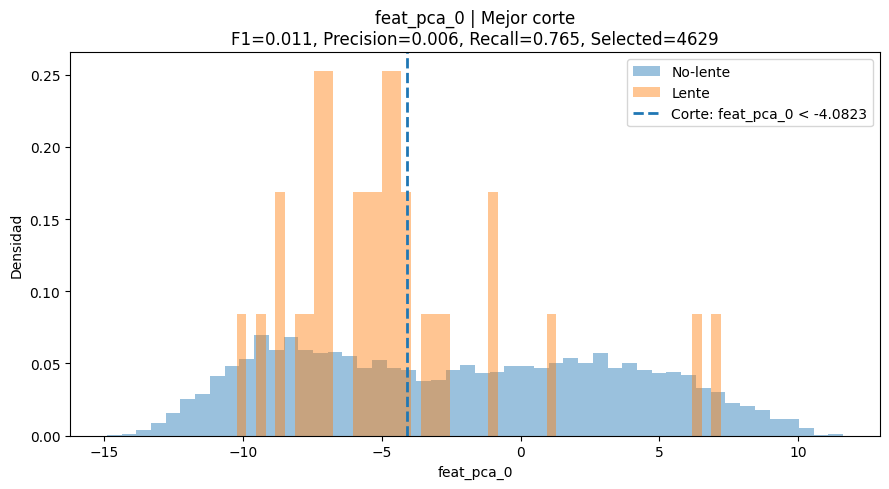

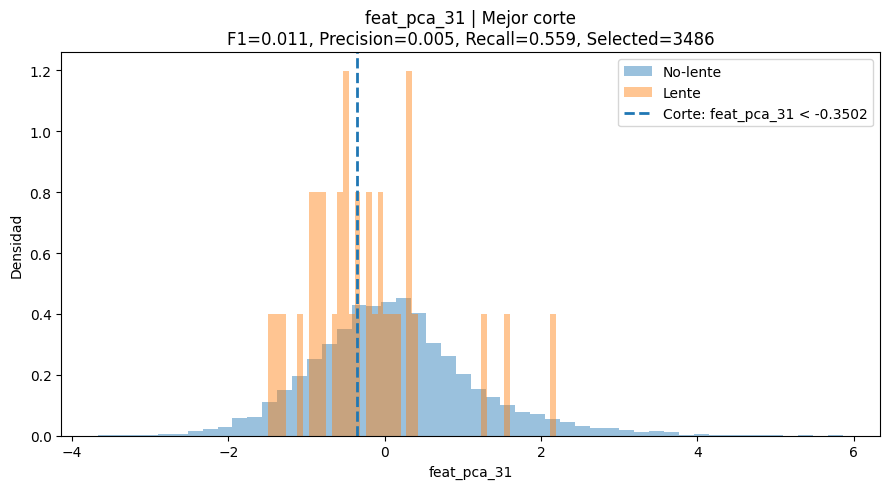

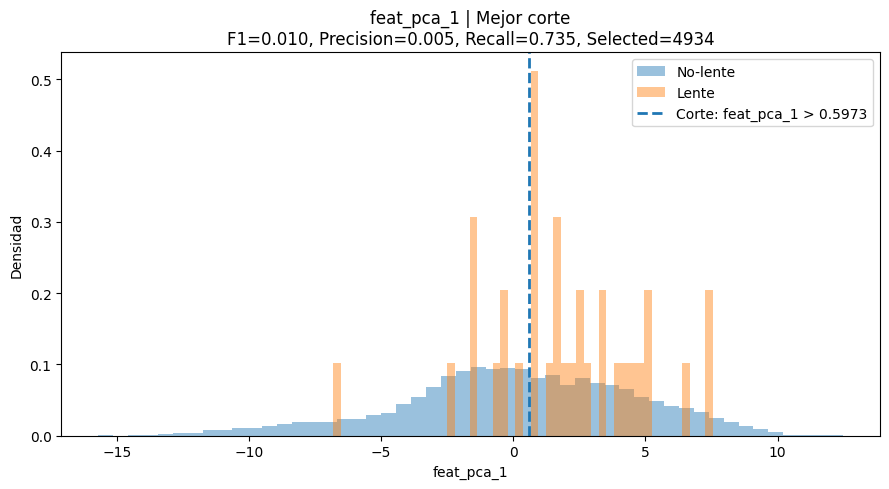

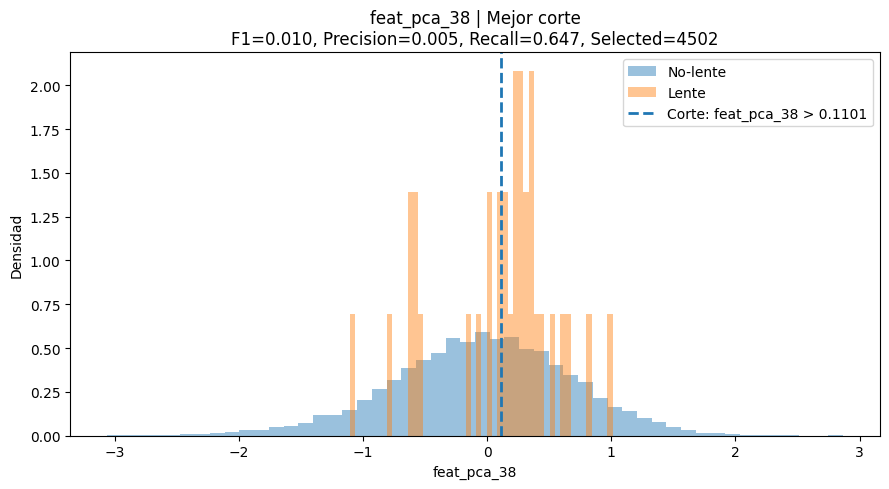

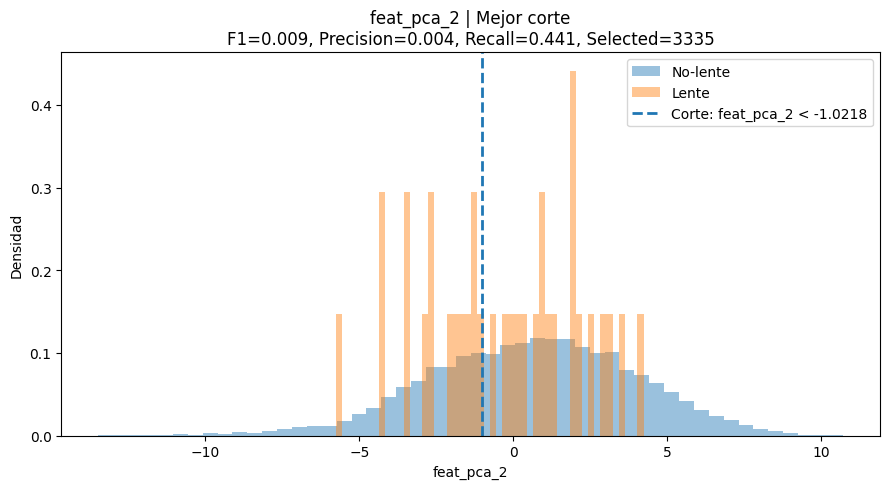

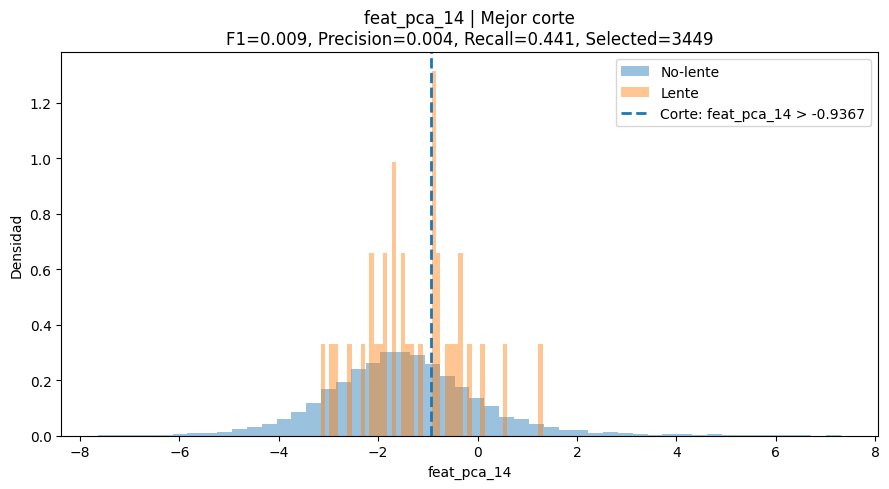

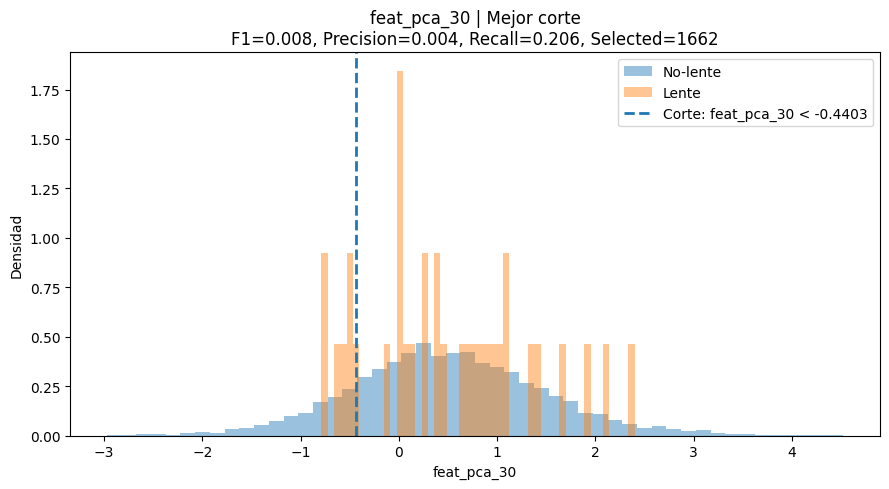

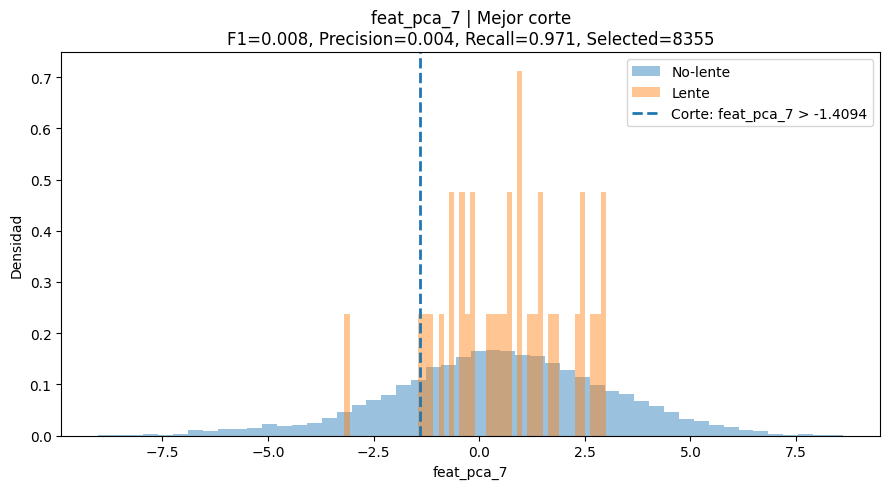

In [15]:
# Ordenamos por F1 descendente
cuts_sorted = cuts_df.sort_values("f1", ascending=False).reset_index(drop=True)

for _, row in cuts_sorted.iterrows():
    feature = row["feature"]
    threshold = row["threshold"]
    direction = row["direction"]

    lens_values = analysis_df[analysis_df["is_lens"]][feature].dropna()
    non_lens_values = analysis_df[~analysis_df["is_lens"]][feature].dropna()

    plt.figure(figsize=(9, 5))

    plt.hist(
        non_lens_values,
        bins=50,
        density=True,
        alpha=0.45,
        label="No-lente",
    )

    plt.hist(
        lens_values,
        bins=50,
        density=True,
        alpha=0.45,
        label="Lente",
    )

    plt.axvline(
        threshold,
        linestyle="--",
        linewidth=2,
        label=f"Corte: {feature} {direction} {threshold:.4f}",
    )

    plt.title(
        f"{feature} | Mejor corte\n"
        f"F1={row['f1']:.3f}, "
        f"Precision={row['precision']:.3f}, "
        f"Recall={row['recall']:.3f}, "
        f"Selected={row['n_selected']}"
    )

    plt.xlabel(feature)
    plt.ylabel("Densidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Cortes que maximizan número de lentes capturadas

In [16]:
MIN_PRECISION = 0.1   # ajustar (0.1–0.5)
N_THRESHOLDS = 300

results = []

for feature in pca_features:
    values = analysis_df[[feature, "is_lens"]].dropna()

    X = values[feature].values
    y = values["is_lens"].astype(int).values

    if len(np.unique(y)) < 2:
        continue

    thresholds = np.linspace(X.min(), X.max(), N_THRESHOLDS)

    best = None

    for direction in [">", "<"]:
        for t in thresholds:

            if direction == ">":
                y_pred = (X > t).astype(int)
            else:
                y_pred = (X < t).astype(int)

            tp = ((y_pred == 1) & (y == 1)).sum()
            fp = ((y_pred == 1) & (y == 0)).sum()
            fn = ((y_pred == 0) & (y == 1)).sum()

            if tp + fp == 0:
                continue

            precision = tp / (tp + fp)
            recall = tp / (tp + fn)

            if precision < MIN_PRECISION:
                continue

            result = {
                "feature": feature,
                "direction": direction,
                "threshold": t,
                "precision": precision,
                "recall": recall,
                "n_lenses_captured": int(tp),
                "n_total_lenses": int(y.sum()),
                "selection_size": int((y_pred == 1).sum()),
            }

            # criterio: maximizar lentes capturados
            if best is None or result["n_lenses_captured"] > best["n_lenses_captured"]:
                best = result

    if best:
        results.append(best)

recall_df = pd.DataFrame(results).sort_values(
    "n_lenses_captured", ascending=False
).reset_index(drop=True)

display(recall_df.head(15))

,feature,direction,threshold,precision,recall,n_lenses_captured,n_total_lenses,selection_size
0,feat_pca_3,<,-7.129600,0.111111,0.029412,1,34,9
1,feat_pca_16,<,-3.488813,1.000000,0.029412,1,34,1
2,feat_pca_29,>,2.748781,0.100000,0.029412,1,34,10
3,feat_pca_32,<,-3.995887,0.200000,0.029412,1,34,5


In [17]:
recall_df["lens_density"] = (
    recall_df["n_lenses_captured"] / recall_df["selection_size"]
)

for _, row in recall_df.iterrows():
    feature = row["feature"]
    direction = row["direction"]
    threshold = row["threshold"]

    n_lenses_captured = int(row["n_lenses_captured"])
    n_total_lenses = int(row["n_total_lenses"])
    selection_size = int(row["selection_size"])

    precision = row["precision"]
    recall = row["recall"]
    lens_density = row["lens_density"]

    print("=" * 80)
    print(f"{feature} {direction} {threshold:.4f}")
    print(f"→ captura {n_lenses_captured} de {n_total_lenses} lentes")
    print(f"→ recall = {recall:.3f}")
    print(f"→ precision = {precision:.3f}")
    print(f"→ densidad de lentes = {lens_density:.3f}")
    print(f"→ selecciona {selection_size} objetos")

feat_pca_3 < -7.1296
→ captura 1 de 34 lentes
→ recall = 0.029
→ precision = 0.111
→ densidad de lentes = 0.111
→ selecciona 9 objetos
feat_pca_16 < -3.4888
→ captura 1 de 34 lentes
→ recall = 0.029
→ precision = 1.000
→ densidad de lentes = 1.000
→ selecciona 1 objetos
feat_pca_29 > 2.7488
→ captura 1 de 34 lentes
→ recall = 0.029
→ precision = 0.100
→ densidad de lentes = 0.100
→ selecciona 10 objetos
feat_pca_32 < -3.9959
→ captura 1 de 34 lentes
→ recall = 0.029
→ precision = 0.200
→ densidad de lentes = 0.200
→ selecciona 5 objetos


In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.feature_selection import mutual_info_classif
from itertools import combinations

# ============================================================
# DATAFRAME DE ANÁLISIS
# ============================================================

TARGET_CLUSTER = 13

analysis_df = work_df[work_df["cluster"] == TARGET_CLUSTER].copy()

if "is_lens" not in analysis_df.columns:
    analysis_df["object_id"] = analysis_df["object_id"].astype("string")
    lens_ids = set(pd.Series(object_id_list, dtype="string").dropna().astype(str))
    analysis_df["is_lens"] = analysis_df["object_id"].isin(lens_ids)

pca_features = [c for c in analysis_df.columns if c.startswith("feat_pca_")]

model_df = analysis_df[pca_features + ["is_lens"]].dropna().copy()

X = model_df[pca_features].to_numpy(dtype=np.float32)
y = model_df["is_lens"].astype(int).to_numpy()

print("Objetos:", len(model_df))
print("Lentes:", y.sum())
print("No-lentes:", len(y) - y.sum())
print("PCA features:", len(pca_features))

Objetos: 10630
Lentes: 34
No-lentes: 10596
PCA features: 40


## Ranking individual de cada componente PCA

In [20]:
# ============================================================
# RANKING INDIVIDUAL DE COMPONENTES PCA
# ============================================================

rows = []

for feature in pca_features:
    x = model_df[feature].to_numpy()

    try:
        auc = roc_auc_score(y, x)
        auc_abs = max(auc, 1 - auc)
    except Exception:
        auc = np.nan
        auc_abs = np.nan

    try:
        ap = average_precision_score(y, x)
    except Exception:
        ap = np.nan

    rows.append({
        "feature": feature,
        "roc_auc_raw": auc,
        "roc_auc_abs": auc_abs,
        "average_precision": ap,
        "lens_mean": model_df.loc[model_df["is_lens"], feature].mean(),
        "non_lens_mean": model_df.loc[~model_df["is_lens"], feature].mean(),
        "abs_mean_diff": abs(
            model_df.loc[model_df["is_lens"], feature].mean()
            - model_df.loc[~model_df["is_lens"], feature].mean()
        )
    })

univariate_df = pd.DataFrame(rows)

# Mutual information
mi = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    "feature": pca_features,
    "mutual_info": mi
})

univariate_df = univariate_df.merge(mi_df, on="feature")

univariate_df = univariate_df.sort_values(
    ["roc_auc_abs", "mutual_info", "average_precision"],
    ascending=False
).reset_index(drop=True)

display(univariate_df.head(15))

,feature,roc_auc_raw,roc_auc_abs,average_precision,lens_mean,non_lens_mean,abs_mean_diff,mutual_info
0,feat_pca_6,0.828415,0.828415,0.020232,3.789845,0.348363,3.441482,0.002469
1,feat_pca_13,0.200880,0.799120,0.001878,-2.207269,-0.454788,1.752481,0.002442
2,feat_pca_27,0.205105,0.794895,0.001888,-1.504142,-0.348384,1.155758,0.001518
3,feat_pca_29,0.783165,0.783165,0.016339,0.624402,-0.140049,0.764451,0.001953
4,feat_pca_34,0.235905,0.764095,0.001963,-0.623630,0.217386,0.841016,0.001402
5,feat_pca_10,0.241170,0.758830,0.001972,-1.577270,0.026514,1.603785,0.001830
6,feat_pca_11,0.268106,0.731894,0.002034,-1.096814,0.227162,1.323976,0.001010
7,feat_pca_8,0.304871,0.695129,0.002139,-1.767580,-0.377390,1.390190,0.001406
8,feat_pca_19,0.309076,0.690924,0.002157,0.476110,1.288648,0.812538,0.001147
9,feat_pca_32,0.309259,0.690741,0.002152,-1.068488,-0.535734,0.532753,0.001806


## Selección de grupo con regresión logística L1

In [21]:
# ============================================================
# SELECCIÓN DE FEATURES CON LOGISTIC REGRESSION L1
# ============================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

pipeline.fit(X, y)

coef = pipeline.named_steps["clf"].coef_[0]

l1_features_df = pd.DataFrame({
    "feature": pca_features,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

selected_l1_df = l1_features_df[l1_features_df["abs_coef"] > 0]

display(selected_l1_df.head(20))

,feature,coef,abs_coef
0,feat_pca_3,-7.223012,7.223012
1,feat_pca_6,5.542101,5.542101
2,feat_pca_4,3.290038,3.290038
3,feat_pca_28,3.007382,3.007382
4,feat_pca_1,-2.894582,2.894582
5,feat_pca_18,-2.879148,2.879148
6,feat_pca_33,-2.498135,2.498135
7,feat_pca_0,-2.359148,2.359148
8,feat_pca_32,-2.330653,2.330653
9,feat_pca_2,-1.983501,1.983501


## Evaluación grupos crecientes de mejores PCA

In [26]:
candidate_features = selected_l1_df["feature"].head(15).tolist()

if len(candidate_features) == 0:
    candidate_features = univariate_df["feature"].head(15).tolist()

group_results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in [1, 2, 3, 4, 5, 8, 10, 15]:
    selected_features = candidate_features[:k]

    if len(selected_features) == 0:
        continue

    X_group = model_df[selected_features].to_numpy(dtype=np.float32)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ])

    scores = cross_validate(
        clf,
        X_group,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "average_precision": "average_precision",
            "f1": "f1",
            "precision": "precision",
            "recall": "recall",
        },
        n_jobs=-1
    )

    group_results.append({
        "n_features": len(selected_features),
        "features": selected_features,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "average_precision_mean": scores["test_average_precision"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
    })

group_results_df = pd.DataFrame(group_results).sort_values(
    "average_precision_mean",
    ascending=False
).reset_index(drop=True)

display(group_results_df)

,n_features,features,roc_auc_mean,average_precision_mean,f1_mean,precision_mean,recall_mean
0,4,"[feat_pca_3, feat_pca_6, feat_pca_4, feat_pca_28]",0.887595,0.122496,0.027141,0.013801,0.823810
1,5,"[feat_pca_3, feat_pca_6, feat_pca_4, feat_pca_...",0.887174,0.118528,0.026205,0.013325,0.795238
2,8,"[feat_pca_3, feat_pca_6, feat_pca_4, feat_pca_...",0.870980,0.096099,0.027793,0.014146,0.795238
3,15,"[feat_pca_3, feat_pca_6, feat_pca_4, feat_pca_...",0.900256,0.094790,0.032605,0.016691,0.709524
4,10,"[feat_pca_3, feat_pca_6, feat_pca_4, feat_pca_...",0.902390,0.082996,0.031409,0.016035,0.766667
5,3,"[feat_pca_3, feat_pca_6, feat_pca_4]",0.875430,0.077641,0.025611,0.013017,0.795238
6,2,"[feat_pca_3, feat_pca_6]",0.843464,0.035555,0.021380,0.010837,0.795238
7,1,[feat_pca_3],0.524580,0.020407,0.006196,0.003119,0.466667


## Búsqueda automática de combinaciones pequeñas (4 componentes PCA)

In [27]:
TOP_N_FEATURES = 12
MAX_COMBINATION_SIZE = 4

candidate_features = univariate_df["feature"].head(TOP_N_FEATURES).tolist()

combo_results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for r in range(2, MAX_COMBINATION_SIZE + 1):
    for combo in combinations(candidate_features, r):

        X_combo = model_df[list(combo)].to_numpy(dtype=np.float32)

        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            ))
        ])

        scores = cross_validate(
            clf,
            X_combo,
            y,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "average_precision": "average_precision",
                "f1": "f1",
                "precision": "precision",
                "recall": "recall",
            },
            n_jobs=-1
        )

        combo_results.append({
            "features": combo,
            "n_features": r,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "average_precision_mean": scores["test_average_precision"].mean(),
            "f1_mean": scores["test_f1"].mean(),
            "precision_mean": scores["test_precision"].mean(),
            "recall_mean": scores["test_recall"].mean(),
        })

combo_results_df = pd.DataFrame(combo_results).sort_values(
    ["average_precision_mean", "f1_mean", "roc_auc_mean"],
    ascending=False
).reset_index(drop=True)

display(combo_results_df.head(20))

,features,n_features,roc_auc_mean,average_precision_mean,f1_mean,precision_mean,recall_mean
0,"(feat_pca_6, feat_pca_13, feat_pca_27, feat_pc...",4,0.895899,0.264643,0.029658,0.015114,0.795238
1,"(feat_pca_6, feat_pca_13, feat_pca_27, feat_pc...",4,0.896544,0.257488,0.030104,0.015359,0.761905
2,"(feat_pca_6, feat_pca_27, feat_pca_34, feat_pc...",4,0.888157,0.254049,0.027950,0.014238,0.766667
3,"(feat_pca_6, feat_pca_27, feat_pca_34, feat_pc...",4,0.891598,0.242911,0.031680,0.016168,0.790476
4,"(feat_pca_27, feat_pca_29, feat_pca_34, feat_p...",4,0.911133,0.237600,0.030474,0.015537,0.795238
5,"(feat_pca_6, feat_pca_27, feat_pca_8, feat_pca...",4,0.884223,0.237214,0.027390,0.013938,0.795238
6,"(feat_pca_6, feat_pca_13, feat_pca_27, feat_pc...",4,0.893222,0.236023,0.030392,0.015497,0.795238
7,"(feat_pca_6, feat_pca_13, feat_pca_27, feat_pc...",4,0.894579,0.234202,0.030538,0.015573,0.795238
8,"(feat_pca_6, feat_pca_27, feat_pca_32, feat_pc...",4,0.875778,0.232941,0.028525,0.014526,0.795238
9,"(feat_pca_6, feat_pca_27, feat_pca_29, feat_pc...",4,0.900223,0.231475,0.031072,0.015851,0.790476


## Mejor grupo de componentes PCA

* **ROC AUC medio**: Capacidad del modelo para ordenar correctamente lentes vs
no-lentes.
* **Average Precision medio**: Resumen de la curva Precision-Recall, cómo de bien se pueden ordenar los objetos para que las lentes aparezcan arriba en el ranking?
* **F1 medio**: Balance entre precision y recall. Cómo de bien detecto lentes sin llenar de ruido?
* **Precision media**: De los objetos seleccionados como lentes, cuántos son realmente lentes?
* **Recall medio**: De todas los lentes reales, cuántas lentes stamos recuperando?

In [25]:
best_combo = combo_results_df.iloc[0]

print("Mejor grupo de componentes PCA:")
print(best_combo["features"])
print()
print(f"Número de componentes: {best_combo['n_features']}")
print(f"ROC AUC medio: {best_combo['roc_auc_mean']:.4f}")
print(f"Average Precision medio: {best_combo['average_precision_mean']:.4f}")
print(f"F1 medio: {best_combo['f1_mean']:.4f}")
print(f"Precision media: {best_combo['precision_mean']:.4f}")
print(f"Recall medio: {best_combo['recall_mean']:.4f}")

Mejor grupo de componentes PCA:
('feat_pca_6', 'feat_pca_13', 'feat_pca_27', 'feat_pca_8')

Número de componentes: 4
ROC AUC medio: 0.8959
Average Precision medio: 0.2646
F1 medio: 0.0297
Precision media: 0.0151
Recall medio: 0.7952


## Mejor threshold individual dentro del grupo

In [28]:
best_pca_group = ["feat_pca_6", "feat_pca_13", "feat_pca_27", "feat_pca_8"]

group_thresholds = []

for feature in best_pca_group:
    result = find_best_cut(analysis_df, feature, n_thresholds=500)
    group_thresholds.append(result)

group_thresholds_df = (
    pd.DataFrame(group_thresholds)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

display(group_thresholds_df)

,feature,direction,threshold,accuracy,precision,recall,f1,n_selected,n_lenses_selected,n_total_lenses,roc_auc_raw,average_precision_raw
0,feat_pca_13,<,-3.494775,0.975729,0.037190,0.264706,0.065217,242,9,34,0.200880,0.001878
1,feat_pca_27,<,-2.758999,0.985889,0.039683,0.147059,0.062500,126,5,34,0.205105,0.001888
2,feat_pca_6,>,7.330005,0.993791,0.055556,0.058824,0.057143,36,2,34,0.828415,0.020232
3,feat_pca_8,<,-2.604952,0.835748,0.007480,0.382353,0.014673,1738,13,34,0.304871,0.002139


## Threshold conjunto para grupo PCA

In [29]:
import itertools

best_pca_group = ["feat_pca_6", "feat_pca_13", "feat_pca_27", "feat_pca_8"]

MIN_SELECTED = 10

# percentiles menos extremos que los cortes individuales
percentiles = [1, 2, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 75, 80, 85, 90, 95, 98, 99]

df = analysis_df.dropna(subset=best_pca_group + ["is_lens"]).copy()
y = df["is_lens"].astype(bool)

rules = []

# probamos direcciones y thresholds por percentiles
candidates = {}

for feature in best_pca_group:
    values = df[feature].values
    candidates[feature] = []

    for p in percentiles:
        t = np.percentile(values, p)
        candidates[feature].append((feature, "<", t))
        candidates[feature].append((feature, ">", t))

# probamos combinaciones de 1, 2, 3 y 4 condiciones
for n_conditions in [1, 2, 3, 4]:
    for combo in itertools.combinations(best_pca_group, n_conditions):

        candidate_lists = [candidates[f] for f in combo]

        for rule_parts in itertools.product(*candidate_lists):

            mask = pd.Series(True, index=df.index)

            rule_text_parts = []

            for feature, direction, threshold in rule_parts:
                if direction == "<":
                    mask &= df[feature] < threshold
                else:
                    mask &= df[feature] > threshold

                rule_text_parts.append(f"{feature} {direction} {threshold:.4f}")

            n_selected = int(mask.sum())

            if n_selected < MIN_SELECTED:
                continue

            n_lenses = int((mask & y).sum())
            n_total_lenses = int(y.sum())
            n_non_lenses = n_selected - n_lenses

            precision = n_lenses / n_selected if n_selected > 0 else 0
            recall = n_lenses / n_total_lenses if n_total_lenses > 0 else 0

            if precision + recall > 0:
                f1 = 2 * precision * recall / (precision + recall)
            else:
                f1 = 0

            rules.append({
                "rule": " AND ".join(rule_text_parts),
                "n_conditions": n_conditions,
                "n_selected": n_selected,
                "n_lenses_selected": n_lenses,
                "n_non_lenses_selected": n_non_lenses,
                "n_total_lenses": n_total_lenses,
                "precision_lens_density": precision,
                "recall": recall,
                "f1": f1,
            })

rules_df = pd.DataFrame(rules)

rules_df = rules_df.sort_values(
    ["n_lenses_selected", "precision_lens_density", "f1"],
    ascending=False
).reset_index(drop=True)

display(rules_df.head(30))

,rule,n_conditions,n_selected,n_lenses_selected,n_non_lenses_selected,n_total_lenses,precision_lens_density,recall,f1
0,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,4,4256,34,4222,34,0.007989,1.0,0.015851
1,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,4,4463,34,4429,34,0.007618,1.0,0.015121
2,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.6040 ...,4,4526,34,4492,34,0.007512,1.0,0.014912
3,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,4,4546,34,4512,34,0.007479,1.0,0.014847
4,feat_pca_6 > -2.5342 AND feat_pca_13 < 0.3794 ...,4,4548,34,4514,34,0.007476,1.0,0.014841
5,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,4,4556,34,4522,34,0.007463,1.0,0.014815
6,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,4,4589,34,4555,34,0.007409,1.0,0.014709
7,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,4,4611,34,4577,34,0.007374,1.0,0.014639
8,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,4,4629,34,4595,34,0.007345,1.0,0.014583
9,feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 ...,3,4664,34,4630,34,0.007290,1.0,0.014474


In [30]:
for _, row in rules_df.head(10).iterrows():
    print("=" * 100)
    print(row["rule"])
    print(f"→ selecciona {int(row['n_selected'])} objetos")
    print(f"→ captura {int(row['n_lenses_selected'])} de {int(row['n_total_lenses'])} lentes")
    print(f"→ densidad de lentes / precision = {row['precision_lens_density']:.4f}")
    print(f"→ recall = {row['recall']:.4f}")
    print(f"→ F1 = {row['f1']:.4f}")

feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 AND feat_pca_27 < 0.5498 AND feat_pca_8 < 2.5524
→ selecciona 4256 objetos
→ captura 34 de 34 lentes
→ densidad de lentes / precision = 0.0080
→ recall = 1.0000
→ F1 = 0.0159
feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 AND feat_pca_27 < 0.5498 AND feat_pca_8 < 3.3929
→ selecciona 4463 objetos
→ captura 34 de 34 lentes
→ densidad de lentes / precision = 0.0076
→ recall = 1.0000
→ F1 = 0.0151
feat_pca_6 > -2.0107 AND feat_pca_13 < 0.6040 AND feat_pca_27 < 0.5498 AND feat_pca_8 < 2.5524
→ selecciona 4526 objetos
→ captura 34 de 34 lentes
→ densidad de lentes / precision = 0.0075
→ recall = 1.0000
→ F1 = 0.0149
feat_pca_6 > -2.0107 AND feat_pca_13 < 0.3794 AND feat_pca_27 < 0.7956 AND feat_pca_8 < 2.5524
→ selecciona 4546 objetos
→ captura 34 de 34 lentes
→ densidad de lentes / precision = 0.0075
→ recall = 1.0000
→ F1 = 0.0148
feat_pca_6 > -2.5342 AND feat_pca_13 < 0.3794 AND feat_pca_27 < 0.5498 AND feat_pca_8 < 2.5524
→ selecciona 4548 obj